<a href="https://colab.research.google.com/github/aabyyaann/midterm-machine-learning/blob/main/clustering_101032300032.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# UTS Machine Learning - Clustering - Naufal Alif Abyan (101032300032)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Identitas
NAMA = "Naufal Alif Abyan"
NIM = "101032300032"

print("Library Clustering siap.")

Library Clustering siap.


In [10]:
drive.mount('/content/drive', force_remount=True)
PATH = "/content/drive/MyDrive/Midterm ML/"

# Memuat dataset clustering
df_cluster = pd.read_csv(PATH + 'clusteringmidterm.csv')

# Preprocessing
# 1. Hapus CUST_ID karena unik untuk setiap user
data = df_cluster.drop('CUST_ID', axis=1)

# 2. Handling Missing Values (Isi dengan median)
data = data.fillna(data.median())

# 3. Handling Outliers dengan Clipping (mencegah cluster terdistorsi nilai ekstrem)
data = data.clip(lower=data.quantile(0.05), upper=data.quantile(0.95), axis=1)

# 4. Scaling Data (Sangat penting untuk K-Means)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print(f"Data siap dikluster: {data_scaled.shape}")

Mounted at /content/drive
Data siap dikluster: (8950, 17)


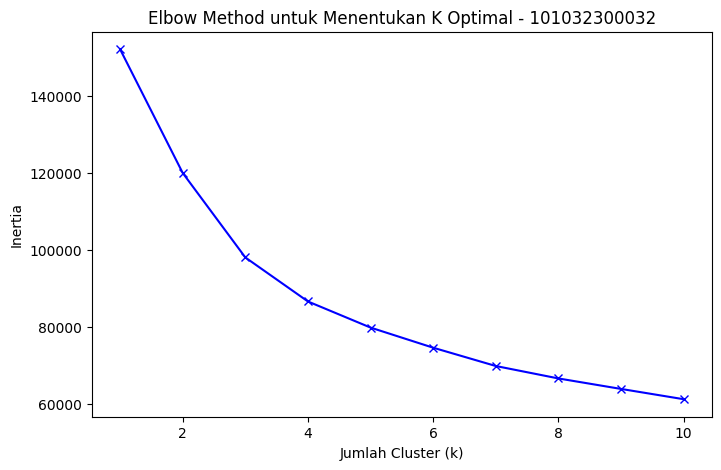

In [11]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title(f'Elbow Method untuk Menentukan K Optimal - {NIM}')
plt.show()

# Berdasarkan grafik, kita akan memilih k=4 (titik di mana penurunan mulai melandai)

--- EVALUASI MODEL ---
NIM: 101032300032
Silhouette Score: 0.1934


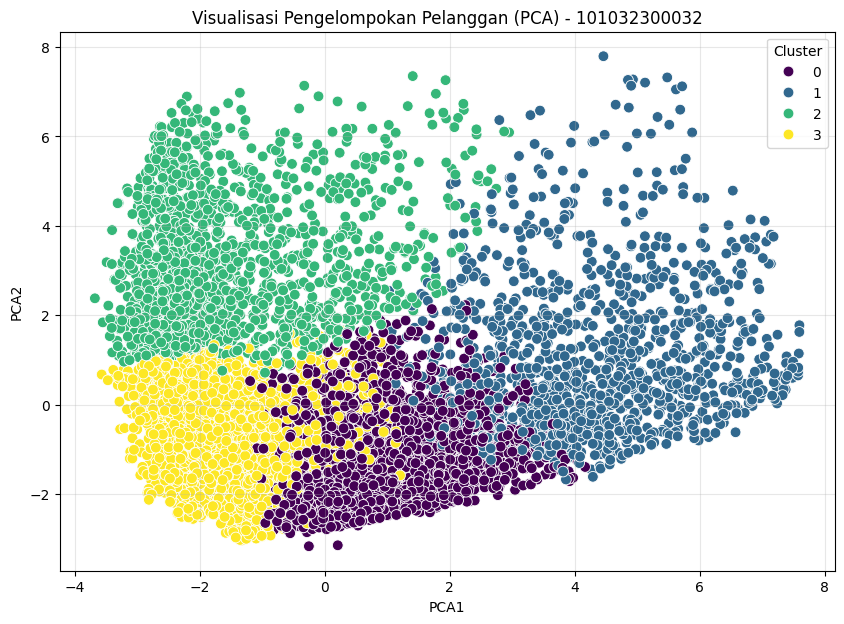


--- ANALISIS KARAKTERISTIK CLUSTER (RATA-RATA) ---


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
Cluster,,,,,
0,634.936323,810.909175,130.001860,3484.672568,937.486495
1,2383.753898,4405.974251,649.515484,7714.823915,4375.738345
2,4001.249307,359.048800,3759.275803,6603.919508,2883.100107
3,863.709999,253.124854,461.485624,3163.675557,883.027223



--- KESIMPULAN ---
Cluster 0: Kelompok pelanggan dengan rata-rata saldo 634.94 dan limit kredit 3484.67
Cluster 1: Kelompok pelanggan dengan rata-rata saldo 2383.75 dan limit kredit 7714.82
Cluster 2: Kelompok pelanggan dengan rata-rata saldo 4001.25 dan limit kredit 6603.92
Cluster 3: Kelompok pelanggan dengan rata-rata saldo 863.71 dan limit kredit 3163.68


In [8]:
# 1. Training Model Final dengan K Optimal (misal k=4)
k_optimal = 4
model_kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = model_kmeans.fit_predict(data_scaled)

# 2. Menambahkan Label Cluster ke Dataframe Asli
df_cluster['Cluster'] = clusters

# 3. Evaluasi Model menggunakan Silhouette Score
# Score mendekati 1 berarti klaster terpisah dengan sangat baik
score = silhouette_score(data_scaled, clusters)
print(f"--- EVALUASI MODEL ---")
print(f"NIM: {NIM}")
print(f"Silhouette Score: {score:.4f}")

# 4. Visualisasi Cluster menggunakan PCA (2D Projection)
# Mengubah banyak fitur menjadi 2 komponen utama agar bisa dilihat di grafik
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
df_pca = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = clusters

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df_pca, palette='viridis', s=60)
plt.title(f'Visualisasi Pengelompokan Pelanggan (PCA) - {NIM}')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Interpretasi Karakteristik Setiap Cluster
# Bagian ini menggunakan numeric_only=True untuk menghindari error pada kolom CUST_ID
print("\n--- ANALISIS KARAKTERISTIK CLUSTER (RATA-RATA) ---")
analysis = df_cluster.groupby('Cluster').mean(numeric_only=True)

# Menampilkan kolom-kolom utama untuk membedakan perilaku belanja
display(analysis[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']])

print("\n--- KESIMPULAN ---")
for i in range(k_optimal):
    print(f"Cluster {i}: Kelompok pelanggan dengan rata-rata saldo {analysis['BALANCE'].iloc[i]:.2f} dan limit kredit {analysis['CREDIT_LIMIT'].iloc[i]:.2f}")